# 01 · The path law in simulation

**What this notebook covers.** A link reports one number for its whole path. Rain
attenuates as a power law of the rain rate, so the attenuation is a path integral,

$$A_{exact} = \int_0^L a\,R(x)^{b}\,dx = a\,L\,\overline{R^{b}},$$

while every retrieval inverts the *linear law* $A_{linear} = a\,\bar R^{\,b} L$, which
assumes the rain is uniform along the path. The two differ when the rain varies along
the path and $b \ne 1$ (Berne & Uijlenhoet, 2007). Here the truth is known: simulated
links of many lengths and frequencies cross six simulated rain regimes, and the gap
between the exact integral and the linear law is measured by length and regime. The
notebook ends with the table a symbolic regression (PySR) would learn $f(\bar R, L)$
from, and the function that scores a learned law.

**Prerequisites.** None: simulation only. Runs in under a minute.

**Contents**
1. Six rain regimes
2. Links of many lengths and frequencies
3. One link: what the integral sees
4. The table
5. The gap, by length and regime
6. Export
7. Your method goes here

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("projects/physics_ml/path_law_1d")
sys.path.insert(0, str(ROOT / "src"))

from core import data_paths as dp
from core.simulation import cml_network as cn
from core.simulation import generators as gen
from core.simulation.rain_fields import Grid
from path_law_1d import simulate as sm

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)
GRID = Grid(n=128, dx_km=0.5)                  # a 64 km periodic domain

## 1. Six rain regimes

Presets of `core.simulation.generators`, from smooth widespread rain to small intense
cells (`sm.REGIMES`). The path law cares about how much the rain varies over the length
of a link, so the regimes are chosen to span that range.

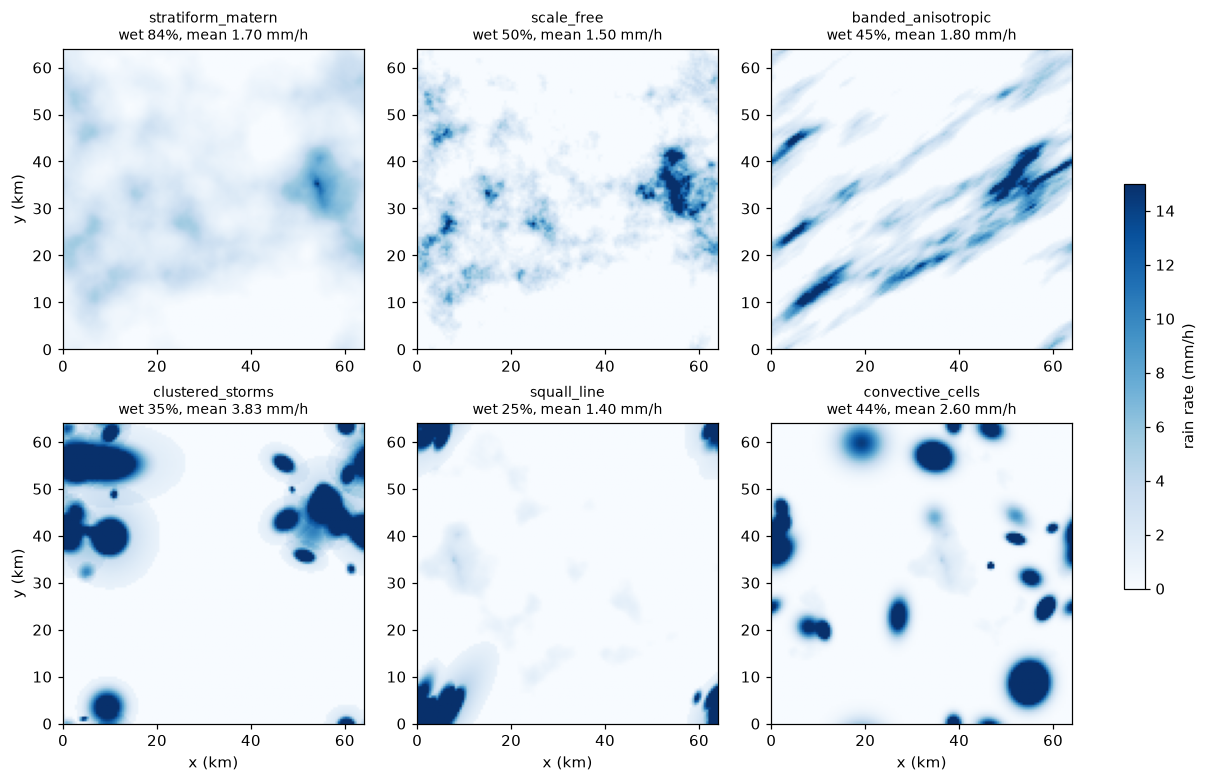

In [2]:
fields = {r: gen.make(r, seed=0).build(GRID) for r in sm.REGIMES}
fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
for ax, (name, f) in zip(axes.flat, fields.items()):
    im = ax.imshow(f, origin="lower", extent=GRID.extent_km, cmap="Blues", vmin=0, vmax=15)
    ax.set_title(f"{name}\nwet {np.mean(f > 0.1):.0%}, mean {f.mean():.2f} mm/h", fontsize=9)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.6, label="rain rate (mm/h)")
for ax in axes[1]:
    ax.set_xlabel("x (km)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (km)")

## 2. Links of many lengths and frequencies

`sm.random_links` draws straight links with log-uniform lengths from 0.3 to 20 km, a
random orientation and a backhaul frequency from 10 to 80 GHz; `(a, b)` come from
ITU-R P.838-3 (`core.itu_p838`). Real networks tie frequency to length (long hops use
low frequencies); here they are drawn independently so the table covers every
combination.

,n_links,total_path_km,mean_length_km,min_length_km,max_length_km,median_freq_ghz,frac_alpha_gt_1
network,800.0,3808.926,4.761,0.303,19.918,26.0,0.39


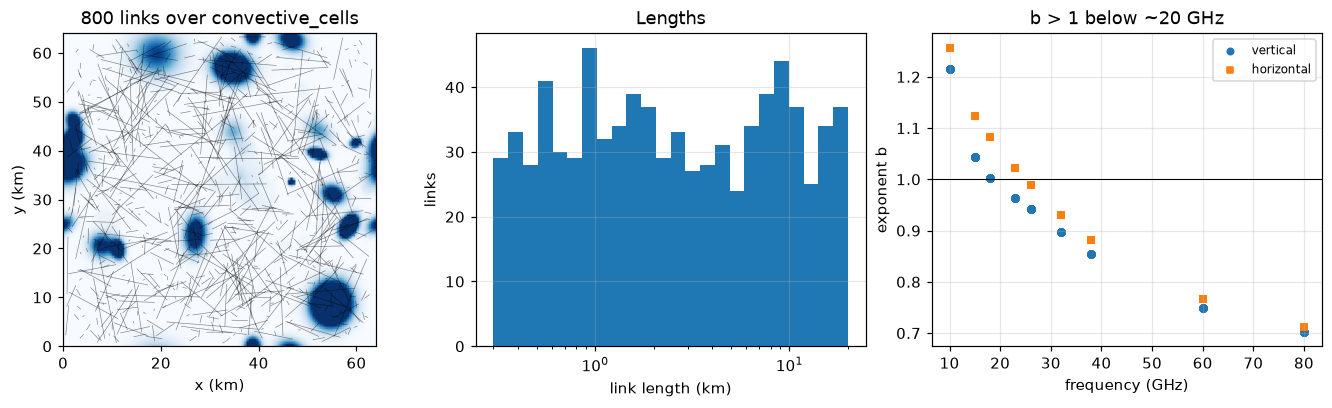

In [3]:
net = sm.random_links(GRID, 800, seed=1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
axes[0].imshow(fields["convective_cells"], origin="lower", extent=GRID.extent_km, cmap="Blues",
               vmin=0, vmax=15)
axes[0].plot(np.c_[net.xa, net.xb].T, np.c_[net.ya, net.yb].T, color="k", lw=0.4, alpha=0.5)
axes[0].set(title="800 links over convective_cells", xlabel="x (km)", ylabel="y (km)")
axes[0].grid(False)
axes[1].hist(net.length_km, bins=np.logspace(np.log10(0.3), np.log10(20), 25), color="C0")
axes[1].set(xscale="log", xlabel="link length (km)", ylabel="links", title="Lengths")
for pol, m in [("vertical", "o"), ("horizontal", "s")]:
    sel = net.pol == pol
    axes[2].scatter(net.freq_ghz[sel], net.alpha[sel], marker=m, s=18, label=pol)
axes[2].axhline(1, color="k", lw=0.7)
axes[2].set(xlabel="frequency (GHz)", ylabel="exponent b", title="b > 1 below ~20 GHz")
axes[2].legend(fontsize=8)
pd.Series(net.summary()).to_frame("network").T

## 3. One link: what the integral sees

The rain along one long link through a convective cell, sampled by
`cml_network.sample_along_paths` (the same sampling the forward model integrates). With
the same rain, a 10 GHz link ($b > 1$) sees more attenuation than the linear law
predicts and an 80 GHz link ($b < 1$) less: Jensen's inequality.

,b,A_exact (dB),A_linear (dB),rain the linear law retrieves / true
f (GHz),,,,
10.0,1.216,1.168,0.751,1.438
23.0,0.963,5.920,6.352,0.929
80.0,0.702,25.789,42.530,0.490


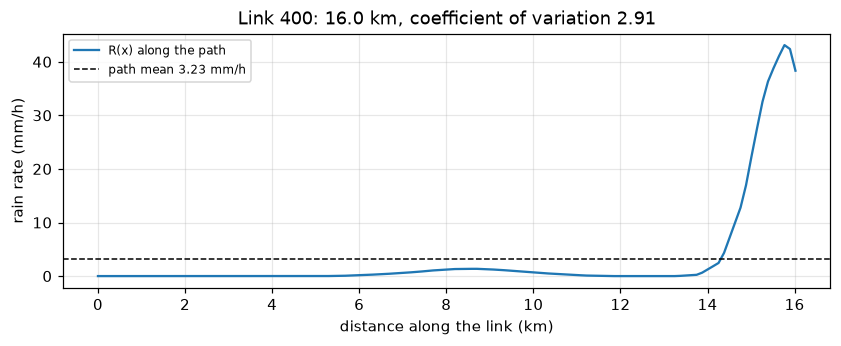

In [4]:
from core.itu_p838 import get_k_alpha

samples = cn.sample_along_paths(fields["convective_cells"], GRID, net)
cv = samples.std(axis=1) / np.maximum(samples.mean(axis=1), 1e-9)
cand = np.flatnonzero((net.length_km > 10) & (samples.mean(axis=1) > 1))
j = cand[np.argmax(cv[cand])]
s, L = samples[j], net.length_km[j]
x = np.linspace(0, L, s.size)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x, s, color="C0", label="R(x) along the path")
ax.axhline(s.mean(), color="k", ls="--", lw=1, label=f"path mean {s.mean():.2f} mm/h")
ax.set(xlabel="distance along the link (km)", ylabel="rain rate (mm/h)",
       title=f"Link {j}: {L:.1f} km, coefficient of variation {cv[j]:.2f}")
ax.legend(fontsize=8)

rows = []
for f_ghz in (10.0, 23.0, 80.0):
    a, b = get_k_alpha(f_ghz, "vertical")
    A_exact, A_lin = a * L * np.mean(s**b), a * L * s.mean() ** b
    rows.append({"f (GHz)": f_ghz, "b": b, "A_exact (dB)": A_exact, "A_linear (dB)": A_lin,
                 "rain the linear law retrieves / true": (A_exact / (a * L)) ** (1 / b) / s.mean()})
pd.DataFrame(rows).set_index("f (GHz)")

## 4. The table

`sm.path_law_table` runs `cml_network.forward_model` with every impairment switched off
(`sm.CLEAN`) on six fields of each regime and keeps every (field, link) pair whose path
mean is at least 0.1 mm/h. `A_exact` is the forward model's `A_rain`, `A_linear` its
`A_uniform`, `R_linear` the rain the linear law retrieves from `A_exact`.

In [5]:
table = sm.path_law_table(net, GRID, n_fields=6, seed=0)
print(f"{len(table)} rows; columns: {', '.join(table.columns)}")
table.groupby("regime", observed=True).agg(
    rows=("R_bar", "size"), median_R_bar=("R_bar", "median"),
    median_cv_path=("cv_path", "median"), median_L_km=("L_km", "median"))

15423 rows; columns: regime, field, link, L_km, f_ghz, pol, a, b, R_bar, cv_path, A_exact, A_linear, R_linear


,rows,median_R_bar,median_cv_path,median_L_km
regime,,,,
stratiform_matern,4159,1.564,0.095,2.574
scale_free,2860,1.607,0.312,2.912
banded_anisotropic,2714,1.972,0.395,3.337
clustered_storms,1844,4.018,0.361,2.923
squall_line,1813,1.204,0.226,2.721
convective_cells,2033,1.646,0.528,3.376


## 5. The gap, by length and regime

The error of the linear law in rain, $R_{linear} / \bar R - 1$. Its sign follows $b - 1$;
its size grows with link length, because a longer path spans more of the rain's
variability, and with how cellular the regime is.

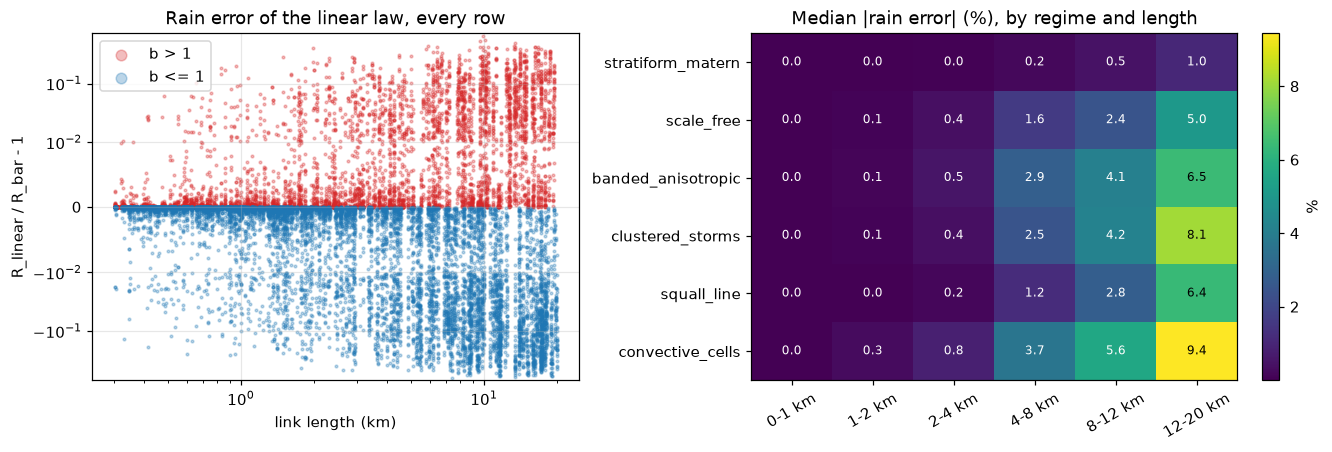

In [6]:
gap = table.R_linear / table.R_bar - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for sel, c, lab in [(table.b > 1, "C3", "b > 1"), (table.b <= 1, "C0", "b <= 1")]:
    axes[0].scatter(table.L_km[sel], gap[sel], s=3, alpha=0.3, color=c, label=lab)
axes[0].set(xscale="log", yscale="symlog", xlabel="link length (km)",
            ylabel="R_linear / R_bar - 1", title="Rain error of the linear law, every row")
axes[0].set_yscale("symlog", linthresh=0.01)
axes[0].legend(markerscale=4)

summary = sm.gap_summary(table, by=("regime",))
heat = summary["median_abs"].unstack("length")
im = axes[1].imshow(heat.values * 100, cmap="viridis", aspect="auto")
axes[1].set_xticks(range(heat.shape[1]), heat.columns, rotation=30)
axes[1].set_yticks(range(heat.shape[0]), heat.index)
for (i, k), v in np.ndenumerate(heat.values * 100):
    axes[1].text(k, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                 color="w" if v < np.nanmax(heat.values) * 60 else "k")
axes[1].set_title("Median |rain error| (%), by regime and length")
axes[1].grid(False)
_ = fig.colorbar(im, ax=axes[1], label="%")

Split by the sign of $b - 1$, so errors of opposite sign do not cancel in the median:

In [7]:
by_sign = sm.gap_summary(table.assign(b_above_1=table.b > 1), by=("b_above_1",))
by_sign[["n", "median", "p10", "p90", "within_5pct"]]

n     median        p10        p90  within_5pct
b_above_1 length                                                      
False     0-1 km    2405 -7.993e-05 -3.173e-03 -2.102e-06        0.988
          1-2 km    1673 -7.383e-04 -2.041e-02 -1.792e-05        0.942
          2-4 km    1253 -2.634e-03 -7.266e-02 -9.390e-05        0.865
          4-8 km    1549 -1.509e-02 -1.522e-01 -6.095e-04        0.711
          8-12 km   1290 -3.372e-02 -2.508e-01 -2.107e-03        0.581
          12-20 km  1295 -6.382e-02 -3.244e-01 -4.784e-03        0.437
True      0-1 km    1625  4.430e-05  6.739e-07  1.817e-03        0.991
          1-2 km     835  3.831e-04  9.096e-06  1.476e-02        0.958
          2-4 km     884  1.846e-03  2.972e-05  5.568e-02        0.888
          4-8 km     904  9.528e-03  2.601e-04  1.094e-01        0.779
          8-12 km    756  1.225e-02  4.152e-04  1.315e-01        0.714
          12-20 km   954  2.724e-02  1.236e-03  1.794e-01        0.623

Where does the linear law hold? The share of (field, link) pairs it gets within 5 % in
rain, by length and regime, and the longest length bin where it holds for 90 % of them:

In [8]:
within = summary["within_5pct"].unstack("length")
overall = sm.gap_summary(table.assign(all="all"), by=("all",))["within_5pct"].droplevel(0)
within.loc["all regimes"] = overall
holds = overall[overall >= 0.9]
print("linear law within 5 % for >= 90 % of cases up to:", holds.index[-1] if len(holds) else "none")
within

linear law within 5 % for >= 90 % of cases up to: 1-2 km


length,0-1 km,1-2 km,2-4 km,4-8 km,8-12 km,12-20 km
regime,,,,,,
stratiform_matern,1.000,0.989,0.973,0.942,0.842,0.821
scale_free,0.985,0.922,0.855,0.705,0.633,0.496
banded_anisotropic,0.977,0.938,0.799,0.609,0.541,0.431
clustered_storms,0.977,0.941,0.866,0.670,0.540,0.381
squall_line,0.994,0.940,0.891,0.773,0.617,0.440
convective_cells,0.994,0.918,0.785,0.580,0.452,0.317
all regimes,0.989,0.947,0.875,0.736,0.630,0.516


## 6. Export

The tidy table, one row per (regime, field, link), is the input a symbolic regression
gets: `R_bar`, `L_km`, `f_ghz`, `pol`, `a`, `b` (and `cv_path`, the variability along
the path, which a real link does not observe) against the target `A_exact`.
Written to `dataset/open_datasets/path_law_1d/` (generated, not committed).

In [9]:
out = dp.OUTPUTS / "path_law_1d" / "simulated_path_law.csv"
out.parent.mkdir(parents=True, exist_ok=True)
table.to_csv(out, index=False)
print(f"wrote {len(table)} rows to {out.relative_to(dp.REPO_ROOT)}")
table.head()

wrote 15423 rows to dataset/open_datasets/path_law_1d/simulated_path_law.csv


,regime,field,link,L_km,f_ghz,pol,a,b,R_bar,cv_path,A_exact,A_linear,R_linear
0,stratiform_matern,0,0,2.574,26.0,horizontal,0.172,0.988,4.200,0.194,1.833,1.833,4.199
1,stratiform_matern,0,1,16.244,10.0,vertical,0.011,1.216,0.972,0.282,0.179,0.177,0.981
2,stratiform_matern,0,2,0.550,15.0,horizontal,0.045,1.123,1.461,0.031,0.038,0.038,1.461
3,stratiform_matern,0,3,16.120,80.0,horizontal,1.170,0.712,0.669,0.392,13.945,14.177,0.654
4,stratiform_matern,0,4,1.111,32.0,vertical,0.265,0.898,0.825,0.045,0.247,0.247,0.825


## 7. Your method goes here

The baseline is the linear law. `sm.score_path_law(table, A_hat)` scores any law: RMSE
in dB, median relative error and the share within 5 %, by length bin. The test rows
are fields 4 and 5 of every regime, which the method must not see while fitting.

In [10]:
train, test = table[table.field < 4], table[table.field >= 4]
print(f"train {len(train)} rows, test {len(test)} rows")
sm.score_path_law(test, test.A_linear)

train 10013 rows, test 5410 rows


,n,rmse_db,median_rel_error,within_5pct
length,,,,
0-1 km,1408,0.003,4.656e-06,0.992
1-2 km,891,0.033,9.072e-05,0.949
2-4 km,778,0.099,2.286e-04,0.906
4-8 km,876,0.731,1.717e-03,0.743
8-12 km,700,1.604,5.697e-03,0.633
12-20 km,757,3.241,4.992e-03,0.527


Replace the placeholder below with a law learned on `train` - for example PySR on
`R_bar`, `L_km`, `a` and `b` with `^` in the operator set (see
`projects/physics_ml/discovery/notebooks/02_pysr_basics.ipynb` for the set-up) - and
score it on `test` with the same function.

In [11]:
# ---- your method goes here ------------------------------------------------------
# model = ...fit on train[["R_bar", "L_km", "a", "b"]] -> train["A_exact"]...
# A_hat = model.predict(test[["R_bar", "L_km", "a", "b"]])
A_hat = test.A_linear.to_numpy()             # placeholder: the linear law
sm.score_path_law(test, A_hat)

,n,rmse_db,median_rel_error,within_5pct
length,,,,
0-1 km,1408,0.003,4.656e-06,0.992
1-2 km,891,0.033,9.072e-05,0.949
2-4 km,778,0.099,2.286e-04,0.906
4-8 km,876,0.731,1.717e-03,0.743
8-12 km,700,1.604,5.697e-03,0.633
12-20 km,757,3.241,4.992e-03,0.527


## References

* Berne, A., and Uijlenhoet, R. (2007). Path-averaged rainfall estimation using microwave
  links: Uncertainty due to spatial rainfall variability. *Geophys. Res. Lett.*, 34, L07403.
  [doi:10.1029/2007GL029409](https://doi.org/10.1029/2007GL029409)
* ITU-R P.838-3 (2005). Specific attenuation model for rain for use in prediction methods.
  <https://www.itu.int/rec/R-REC-P.838-3-200503-I/en>
* Cranmer, M. (2023). Interpretable machine learning for science with PySR and
  SymbolicRegression.jl. [arXiv:2305.01582](https://arxiv.org/abs/2305.01582)